In [2]:
!sudo apt-get install -y zstd

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [3]:
!curl -fsSL https://ollama.ai/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [4]:
import subprocess
import time

subprocess.Popen(["ollama", "serve"])
time.sleep(5)  # Give it time to initialize
print("Ollama server started!")

Ollama server started!


In [5]:
!ollama pull deepseek-r1:7b     # Good balance — recommended for free tier
!ollama pull deepseek-r1:1.5b   # Smallest / fastest
!ollama pull deepseek-r1:8b     # Slightly larger, still fits on T4

In [9]:
!ollama ps

NAME              ID              SIZE      PROCESSOR    CONTEXT    UNTIL              
deepseek-r1:7b    755ced02ce7b    4.9 GB    100% GPU     4096       4 minutes from now    


In [8]:
!pip install ollama

import ollama

response = ollama.chat(
    model='deepseek-r1:7b',
    messages=[{'role': 'user', 'content': 'Explain how neural networks work.'}]
)
print(response['message']['content'])

Neural networks operate as computational models inspired by biological brains. Here's an organized explanation of their function:

1. **Structure**: Neural networks consist of layers:
   - **Input Layer**: Receives raw data (e.g., images or numbers).
   - **Hidden Layers**: Located between input and output, these layers process information using weights and biases.
   - **Output Layer**: Produces the final predictions.

2. **Functionality**:
   - Each node in a layer represents a neuron that receives inputs, processes them, and passes results to the next layer.
   - Inputs are weighted by coefficients (weights) before being summed with bias terms.
   - Activation functions (e.g., ReLU, sigmoid) convert these sums into outputs, determining if a neuron "fires."

3. **Learning Process**:
   - **Forward Propagation**: Input data flows through layers, transformed by weights and biases, to produce an output.
   - **Backpropagation**: Errors are computed at the output layer, propagated backwa

In [10]:
!pip install gradio

import gradio as gr
import ollama

def chat(message, history):
    response = ollama.chat(
        model='deepseek-r1:7b',
        messages=[{'role': 'user', 'content': message}]
    )
    return response['message']['content']

gr.ChatInterface(chat).launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d3cbac73092b6606c5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


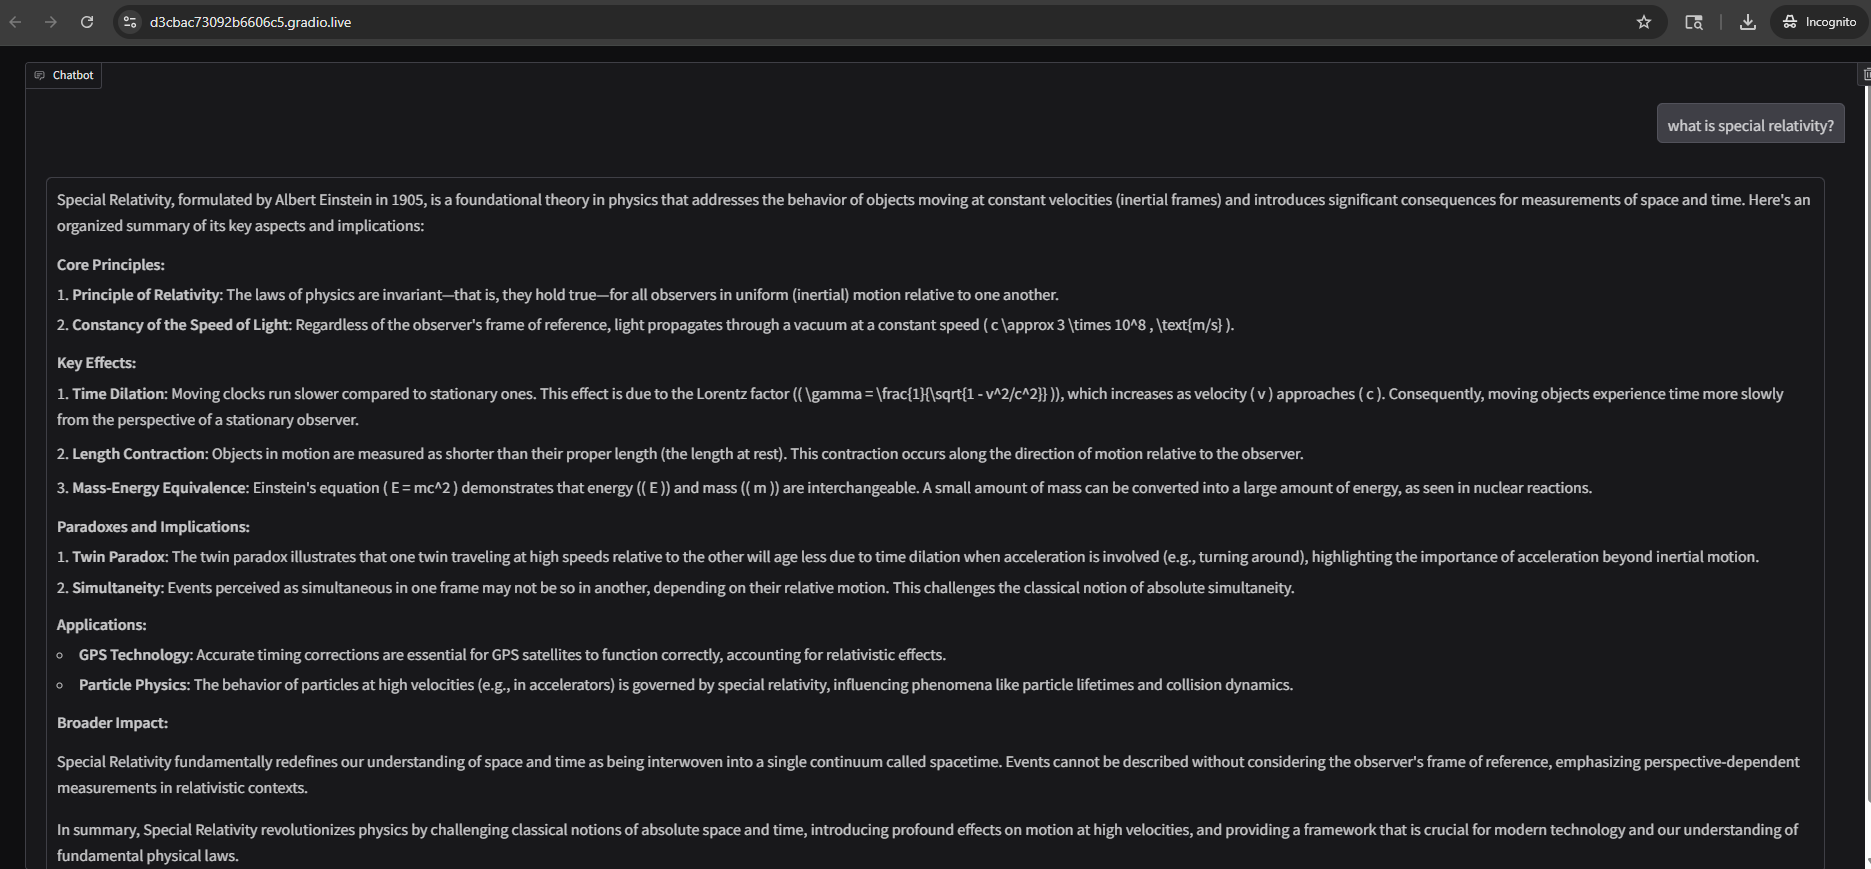